# Whole-Blob Validation Eval (No `LineSegmenter`)

This notebook evaluates the detector-only OCR path against `labels/labels.json`:

`frame -> TopLeftBlueGrayBoxDetector -> full ROI -> gray_x3_lanczos -> OCR -> LineFirstParser -> score_predictions`

It keeps the `gray_x3_lanczos` preprocessing from the sweep, but does **not** use `LineSegmenter`, per-line crops, or char fallback. Parser-based exact-match scoring is the primary metric; raw whole-panel OCR text is kept for diagnostics.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def find_repo(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "app" / "pipeline" / "echo_ocr_pipeline.py").is_file():
            return path
    raise RuntimeError("Run this notebook from the Master repo.")


REPO = find_repo(Path.cwd().resolve())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

print("REPO:", REPO)

REPO: /home/warre/Documents/howest/Semester_5/Stage/StageOpdracht/Master


In [2]:
from dataclasses import asdict
import os
import time

try:
    from IPython.display import display
except Exception:
    def display(value):
        print(value)

import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except Exception:
    pd = None

from app.io.dicom_loader import load_dicom_series
from app.pipeline.layout.echo_ocr_box_detector import TopLeftBlueGrayBoxDetector
from app.pipeline.measurements.line_first_parser import LineFirstParser
from app.pipeline.ocr.ocr_engines import UnavailableOcrEngineError, build_engine
from app.tools.batch.sweep_preprocessing_headless import _broad_configs, _build_preprocess_views
from app.validation.datasets import canonicalize_label_line, parse_labels
from app.validation.evaluation import score_predictions

In [3]:
LABELS_JSON = REPO / "labels" / "labels.json"
CONFIG_NAME = "gray_x3_lanczos"
ENGINE_NAME = "glm-ocr"
SPLIT = "validation"
ONLY_NAMES: set[str] | None = None  # e.g. {"92290733_0035.dcm"}
MAX_FILES: int | None = None        # e.g. 10 for a smoke run
FAILURE_PREVIEW_LIMIT = 25
DIAG_NAME: str | None = None
EXTERNAL_DICOM_ROOT = Path("/run/media/warre/T7/MIMIC-IV-ECHO/files")

if not LABELS_JSON.is_file():
    raise FileNotFoundError(f"Missing labels file: {LABELS_JSON}")
if EXTERNAL_DICOM_ROOT.is_dir():
    os.environ["ECHO_OCR_DICOM_ROOT"] = str(EXTERNAL_DICOM_ROOT)
    print(f"Using ECHO_OCR_DICOM_ROOT={EXTERNAL_DICOM_ROOT}")

sweep_cfg = next(cfg for cfg in _broad_configs() if cfg.name == CONFIG_NAME)
preprocess_full_roi = _build_preprocess_views(sweep_cfg)["default"]
detector = TopLeftBlueGrayBoxDetector()
parser = LineFirstParser()

try:
    engine = build_engine(ENGINE_NAME)
except UnavailableOcrEngineError as exc:
    raise RuntimeError(f"Could not start OCR engine {ENGINE_NAME!r}: {exc}") from exc

labeled_files = parse_labels(LABELS_JSON, split_filter={SPLIT})
if ONLY_NAMES is not None:
    labeled_files = [item for item in labeled_files if item.file_name in ONLY_NAMES]
if MAX_FILES is not None:
    labeled_files = labeled_files[: int(MAX_FILES)]

labeled_by_name = {item.file_name: item for item in labeled_files}

print(f"Loaded {len(labeled_files)} labeled files from split={SPLIT!r}")
print(f"Preprocess config: {CONFIG_NAME}")
print(f"OCR engine: {engine.name}")

The image processor of type `Glm46VImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loaded 353 labeled files from split='validation'
Preprocess config: gray_x3_lanczos
OCR engine: glm-ocr


In [4]:
def prediction_to_line(prediction: dict[str, str | None]) -> str:
    parts = [
        str(prediction.get("name") or "").strip(),
        str(prediction.get("value") or "").strip(),
        str(prediction.get("unit") or "").strip(),
    ]
    return canonicalize_label_line(" ".join(part for part in parts if part))


def measurement_to_prediction(measurement) -> dict[str, str | None]:
    return {
        "name": getattr(measurement, "name", None),
        "value": getattr(measurement, "value", None),
        "unit": getattr(measurement, "unit", None),
    }


def display_table(rows: list[dict], *, limit: int | None = None) -> None:
    shown = rows if limit is None else rows[:limit]
    if pd is not None:
        display(pd.DataFrame(shown))
        return
    for row in shown:
        print(row)


def run_file_eval(labeled_file) -> dict[str, object]:
    started = time.perf_counter()
    series = load_dicom_series(labeled_file.path, load_pixels=True)

    all_predictions: list[dict[str, str | None]] = []
    frame_records: list[dict[str, object]] = []

    for frame_index in range(series.frame_count):
        frame = series.get_frame(frame_index)
        detection = detector.detect(frame)
        if not detection.present or detection.bbox is None:
            frame_records.append(
                {
                    "frame_index": frame_index,
                    "roi_bbox": None,
                    "roi_confidence": float(detection.confidence),
                    "raw_ocr_text": "",
                    "parsed_lines": [],
                }
            )
            continue

        x, y, bw, bh = detection.bbox
        roi = frame[y : y + bh, x : x + bw]
        prepared = preprocess_full_roi(roi)
        ocr_result = engine.extract(prepared)
        parsed_measurements = parser.parse(ocr_result.text, confidence=max(float(ocr_result.confidence), 1e-6))
        frame_predictions = [measurement_to_prediction(item) for item in parsed_measurements]
        all_predictions.extend(frame_predictions)

        frame_records.append(
            {
                "frame_index": frame_index,
                "roi_bbox": tuple(int(v) for v in detection.bbox),
                "roi_confidence": float(detection.confidence),
                "raw_ocr_text": ocr_result.text,
                "parsed_lines": [prediction_to_line(item) for item in frame_predictions],
            }
        )

    match_results = score_predictions(labeled_file.measurements, all_predictions)
    elapsed_s = time.perf_counter() - started

    return {
        "file_name": labeled_file.file_name,
        "file_path": str(labeled_file.path),
        "split": labeled_file.split,
        "labels": [item.text for item in labeled_file.measurements],
        "predicted_lines": [prediction_to_line(item) for item in all_predictions],
        "raw_ocr_text": "\n\n".join(
            f"[frame {item['frame_index']}]\n{item['raw_ocr_text']}"
            for item in frame_records
            if item["raw_ocr_text"]
        ),
        "frames": frame_records,
        "matches": [asdict(item) for item in match_results],
        "total_labels": len(labeled_file.measurements),
        "full_matches": sum(1 for item in match_results if item.full_match),
        "line_matches": sum(1 for item in match_results if item.line_match),
        "value_matches": sum(1 for item in match_results if item.value_match),
        "label_matches": sum(1 for item in match_results if item.label_match),
        "prefix_matches": sum(1 for item in match_results if item.prefix_match),
        "predicted_count": len(all_predictions),
        "detected_frame_count": sum(1 for item in frame_records if item["roi_bbox"] is not None),
        "elapsed_s": elapsed_s,
    }

In [5]:
results: list[dict[str, object]] = []
errors: list[dict[str, str]] = []

for index, labeled_file in enumerate(labeled_files, start=1):
    if index == 1 or index % 25 == 0 or index == len(labeled_files):
        print(f"[{index}/{len(labeled_files)}] {labeled_file.file_name}")
    try:
        results.append(run_file_eval(labeled_file))
    except Exception as exc:
        errors.append(
            {
                "file_name": labeled_file.file_name,
                "file_path": str(labeled_file.path),
                "error": repr(exc),
            }
        )

results_by_name = {item["file_name"]: item for item in results}

summary_rows = [{
    "files_processed": len(results),
    "files_failed": len(errors),
    "files_with_detected_roi": sum(1 for item in results if int(item["detected_frame_count"]) > 0),
    "total_labels": sum(int(item["total_labels"]) for item in results),
    "exact_matches": sum(int(item["full_matches"]) for item in results),
    "exact_errors": sum(int(item["total_labels"]) for item in results) - sum(int(item["full_matches"]) for item in results),
    "line_matches": sum(int(item["line_matches"]) for item in results),
    "value_matches": sum(int(item["value_matches"]) for item in results),
    "predicted_measurements": sum(int(item["predicted_count"]) for item in results),
    "mean_seconds_per_file": round(
        sum(float(item["elapsed_s"]) for item in results) / max(len(results), 1),
        3,
    ),
}]
summary = summary_rows[0]
summary["exact_match_rate"] = round(summary["exact_matches"] / max(summary["total_labels"], 1), 4)
summary["line_match_rate"] = round(summary["line_matches"] / max(summary["total_labels"], 1), 4)
summary["value_match_rate"] = round(summary["value_matches"] / max(summary["total_labels"], 1), 4)

failure_rows: list[dict[str, object]] = []
for item in results:
    if int(item["full_matches"]) == int(item["total_labels"]):
        continue
    failure_rows.append(
        {
            "file_name": item["file_name"],
            "total_labels": item["total_labels"],
            "exact_matches": item["full_matches"],
            "exact_errors": int(item["total_labels"]) - int(item["full_matches"]),
            "predicted_count": item["predicted_count"],
            "detected_frame_count": item["detected_frame_count"],
            "labels": " | ".join(item["labels"]),
            "predicted_lines": " | ".join(item["predicted_lines"]),
            "raw_ocr_text": item["raw_ocr_text"],
        }
    )

failure_rows.sort(key=lambda row: (-int(row["exact_errors"]), str(row["file_name"])))

print("Summary")
display_table(summary_rows)
print(f"Failure files: {len(failure_rows)}")
if errors:
    print(f"Load/runtime errors: {len(errors)}")

[1/353] 91243943_0004.dcm
[25/353] 91629559_0027.dcm
[50/353] 92290733_0071.dcm
[75/353] 93330659_0103.dcm
[100/353] 93489296_0068.dcm
[125/353] 94106955_0046.dcm
[150/353] 94134445_0042.dcm
[175/353] 95253372_0042.dcm
[200/353] 97273331_0029.dcm
[225/353] 97555635_0102.dcm
[250/353] 98667422_0037.dcm
[275/353] 99094104_0042.dcm
[300/353] 99583722_0015.dcm
[325/353] 99583722_0092.dcm
[350/353] 99663585_0107.dcm
[353/353] 99663585_0110.dcm
Summary
{'files_processed': 191, 'files_failed': 162, 'files_with_detected_roi': 191, 'total_labels': 490, 'exact_matches': 398, 'exact_errors': 92, 'line_matches': 398, 'value_matches': 440, 'predicted_measurements': 450, 'mean_seconds_per_file': 0.573, 'exact_match_rate': 0.8122, 'line_match_rate': 0.8122, 'value_match_rate': 0.898}
Failure files: 53
Load/runtime errors: 162


In [6]:
print("Top failure rows")
display_table(failure_rows, limit=FAILURE_PREVIEW_LIMIT)

if errors:
    print("File-level errors")
    display_table(errors, limit=FAILURE_PREVIEW_LIMIT)

Top failure rows
{'file_name': '91243943_0033.dcm', 'total_labels': 3, 'exact_matches': 0, 'exact_errors': 3, 'predicted_count': 1, 'detected_frame_count': 1, 'labels': '1 LALs A4C 6.1 cm | LAAs A4C 23.4 cm2 | LAESV A-L A4C 77 ml', 'predicted_lines': '1 LALs A4C 6.1 cm LAAs A4C 23.4 cm2 LAESV A-L A4C 77 ml', 'raw_ocr_text': '[frame 0]\n1 LALs A4C 6.1 cm LAAs A4C 23.4 cm2 LAESV A-L A4C 77 ml'}
{'file_name': '91629559_0041.dcm', 'total_labels': 3, 'exact_matches': 0, 'exact_errors': 3, 'predicted_count': 1, 'detected_frame_count': 1, 'labels': '1 LALs A4C 6.0 cm | LAAS A4C 24.5 cm2 | LAESV A-L A4C 84 ml', 'predicted_lines': '1 LALs A4C 6.0 cm LAAs A4C 24.5 cm2 LAESV A-L A4C 84 ml', 'raw_ocr_text': '[frame 0]\n1 LALs A4C 6.0 cm LAAs A4C 24.5 cm2 LAESV A-L A4C 84 ml'}
{'file_name': '92290733_0045.dcm', 'total_labels': 3, 'exact_matches': 0, 'exact_errors': 3, 'predicted_count': 1, 'detected_frame_count': 1, 'labels': '1 LVOT Vmax 0.9 m/s | LVOT maxPG 3 mmHg | LVOT VTI 17.6 cm', 'predicted_

91243943_0033.dcm
Expected labels:
  - 1 LALs A4C 6.1 cm
  - LAAs A4C 23.4 cm2
  - LAESV A-L A4C 77 ml
Parsed predictions:
  - 1 LALs A4C 6.1 cm LAAs A4C 23.4 cm2 LAESV A-L A4C 77 ml
Raw OCR text:
[frame 0]
1 LALs A4C 6.1 cm LAAs A4C 23.4 cm2 LAESV A-L A4C 77 ml


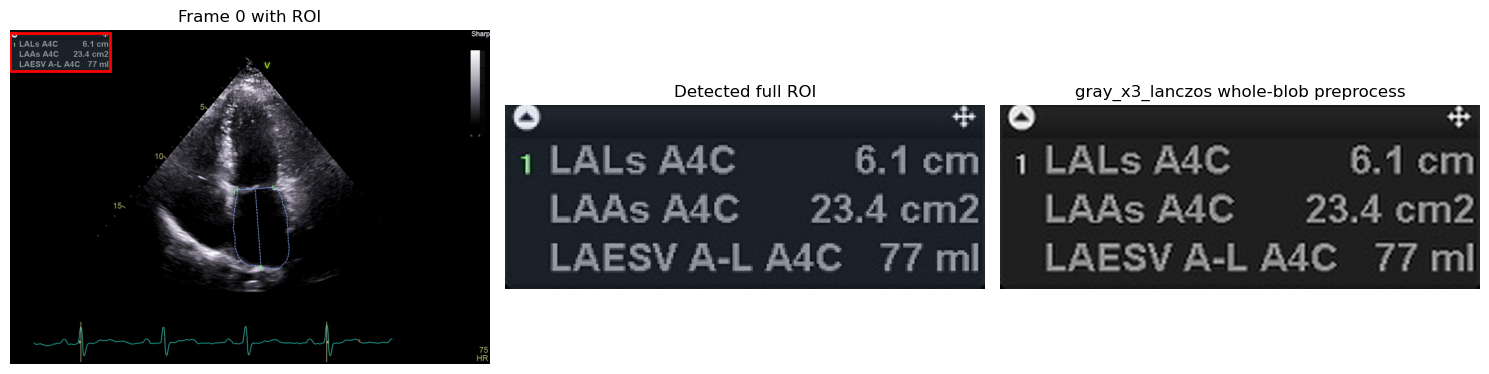

In [7]:
def render_failure_diagnostics(file_name: str) -> None:
    result = results_by_name[file_name]
    labeled_file = labeled_by_name[file_name]
    series = load_dicom_series(labeled_file.path, load_pixels=True)

    chosen = None
    for frame_index in range(series.frame_count):
        frame = series.get_frame(frame_index)
        detection = detector.detect(frame)
        if not detection.present or detection.bbox is None:
            continue
        x, y, bw, bh = detection.bbox
        roi = frame[y : y + bh, x : x + bw]
        prepared = preprocess_full_roi(roi)
        ocr_result = engine.extract(prepared)
        chosen = {
            "frame": frame,
            "frame_index": frame_index,
            "bbox": detection.bbox,
            "roi": roi,
            "prepared": prepared,
            "ocr_text": ocr_result.text,
        }
        break

    print(file_name)
    print("Expected labels:")
    for line in result["labels"]:
        print("  -", line)

    print("Parsed predictions:")
    if result["predicted_lines"]:
        for line in result["predicted_lines"]:
            print("  -", line)
    else:
        print("  - NONE")

    print("Raw OCR text:")
    print(result["raw_ocr_text"] or "<empty>")

    if chosen is None:
        print("No detected ROI for visualization.")
        return

    frame = chosen["frame"]
    x, y, bw, bh = chosen["bbox"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    if frame.ndim == 2:
        axes[0].imshow(frame, cmap="gray")
    else:
        axes[0].imshow(frame[..., :3].astype(np.uint8, copy=False))
    rect = plt.Rectangle((x, y), bw, bh, fill=False, edgecolor="red", linewidth=2)
    axes[0].add_patch(rect)
    axes[0].set_title(f"Frame {chosen['frame_index']} with ROI")
    axes[0].axis("off")

    roi = chosen["roi"]
    if roi.ndim == 2:
        axes[1].imshow(roi, cmap="gray")
    else:
        axes[1].imshow(roi[..., :3].astype(np.uint8, copy=False))
    axes[1].set_title("Detected full ROI")
    axes[1].axis("off")

    axes[2].imshow(chosen["prepared"], cmap="gray")
    axes[2].set_title(f"{CONFIG_NAME} whole-blob preprocess")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


if DIAG_NAME is None and failure_rows:
    DIAG_NAME = str(failure_rows[0]["file_name"])

if DIAG_NAME is not None:
    render_failure_diagnostics(DIAG_NAME)
else:
    print("No failures to inspect.")